In [1]:
import csv

import pandas as pd
import numpy as np
import sqlite3 as sql3
from matplotlib import pyplot as plt
import csv

# Task 0
Data extraction: get the data from 3 tables & combine it into single `.csv` file.
After that read this file using pandas to create Dataframe.
So it will be all joined data in 1 dataframe. Quick check - should be 74818 rows in it.

In [2]:
# write your code here
cx = sql3.connect("../db.sqlite3")
cu = cx.cursor()
cu.execute("""SELECT
    restaurant_orderitem.order_id,
    restaurant_order.datetime,
    restaurant_product.name AS product_name,
    restaurant_orderitem.quantity,
    restaurant_product.price
    FROM restaurant_orderitem 
    JOIN restaurant_order ON restaurant_order.id = restaurant_orderitem.order_id 
    JOIN restaurant_product ON restaurant_product.id = restaurant_orderitem.product_id 
    """
)
rows = cu.fetchall()
columns = [desc[0] for desc in cu.description]
# with open("restaurant_orders.csv", "w", newline="") as csvfile:
#     csvwriter = csv.writer(csvfile, delimiter=",")
#     
#     csvwriter.writerow(columns)
#     csvwriter.writerows(rows)
    
df = pd.read_csv("restaurant_orders.csv")
df.head()

,order_id,datetime,product_name,quantity,price
0,1,2019-08-03 20:25:00,Plain Papadum,2,0.80
1,1,2019-08-03 20:25:00,King Prawn Balti,1,12.95
2,1,2019-08-03 20:25:00,Garlic Naan,1,2.95
3,1,2019-08-03 20:25:00,Mushroom Rice,1,3.95
4,1,2019-08-03 20:25:00,Paneer Tikka Masala,1,8.95


# Task 1
Get Top 10 most popular products in restaurant sold by Quantity.
Count how many times each product was sold and create a pie chart with percentage of popularity (by quantity) for top 10 of them.

Example:

![pie chart](../demo/pie.png)

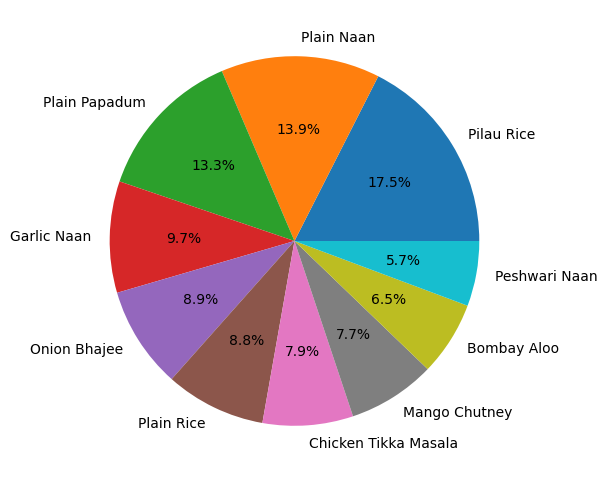

In [3]:
# write your code here
count_items = df.groupby("product_name")["order_id"].count().sort_values(ascending=False)
sum_items = df.groupby("product_name")["quantity"].sum()
top_items = count_items.head(10)
popularity = (top_items / sum_items.sum()) * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.pie(popularity, labels=top_items.keys(), autopct="%1.1f%%")
plt.show()

# Task 2
Calculate `Item Price` (Product Price * Quantity) for each Order Item in dataframe.
And Make the same Top 10 pie chart, but this time by `Item Price`. So this chart should describe not the most popular products by quantity, but which products (top 10) make the most money for restaurant. It should be also with percentage.

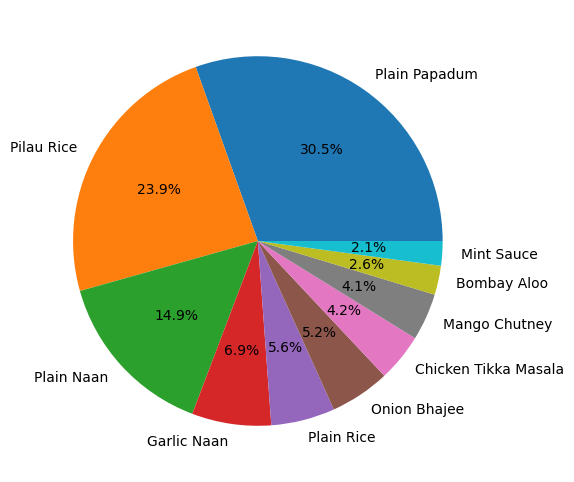

In [4]:
# write your code here
prices = df.groupby("product_name")["price"].count()
costs = sum_items * prices
top_costs = costs.sort_values(ascending=False).head(10)
popular_products = (top_costs / costs.sum()) * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.pie(popular_products, labels=popular_products.keys(), autopct="%1.1f%%")
plt.show()

# Task 3
Calculate `Order Hour` based on `Order Datetime`, which will tell about the specific our the order was created (from 0 to 23). Using `Order Hour` create a bar chart, which will tell the total restaurant income based on the hour order was created. So on x-axis - it will be values from 0 to 23 (hours), on y-axis - it will be the total sum of order prices, which were sold on that hour.

Example:

![bar chart](../demo/bar.png)

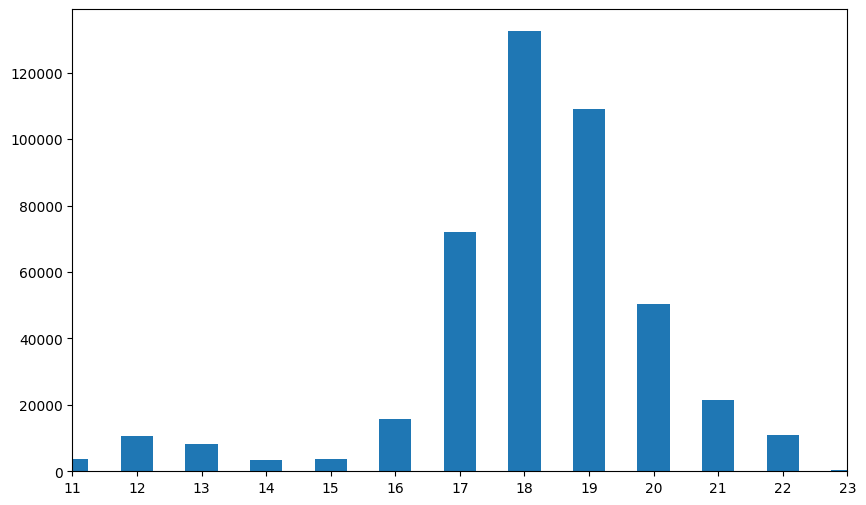

In [5]:
# write your code here
df["hours"] = pd.to_datetime(df["datetime"]).dt.hour
df["total_costs"] = df["price"] * df["quantity"]
costs_in_hour = df.groupby("hours")["total_costs"].sum()
hour_labels = costs_in_hour.index

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(hour_labels, costs_in_hour, width=0.5)
ax.set_xticks(hour_labels)
ax.set_xlim(11, 23)
plt.show()


# Task 4
Make similar bar chart, but right now with `Order Day Of The Week` (from Monday to Sunday), and also analyze total restaurant income by each day of the week.

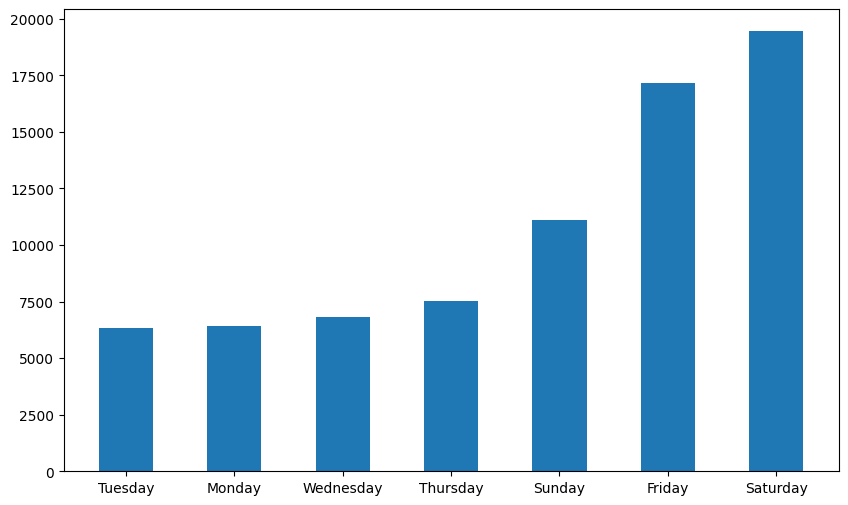

In [27]:
# write your code here
df["weekday"] = pd.to_datetime(df["datetime"]).dt.day_name()
all_orders_costs = df.groupby("order_id")["total_costs"].sum()
orders_per_day = df.groupby("weekday")["order_id"].count().sort_values()
weekdays_orders = df.groupby("weekday")["order_id"].sum()
# labels = weekdays_orders.index

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(orders_per_day.index, orders_per_day.values, width=0.5)
plt.show()